# A quantum geometry of chatbot interaction

This notebook demoes the pipeline of
[rel-int/internal-issues#14](https://github.com/rel-int/internal-issues/issues/14),
building on the abstract categorial grammars of
[#400](https://github.com/discopy/discopy/pull/400)
and the token-machine decoding of lambda terms of
[#401](https://github.com/discopy/discopy/pull/401):

1. a sentence is parsed into a diagram by a categorial grammar,
2. the diagram is bracketed into **bubbles** of a maximal size, the inside
   of each bubble is compiled to a **quantum circuit** called by the
   outside, a Python function with disjoint union as tensor
   (:mod:`discopy.python.additive`),
3. a classical token travels around the diagram — **additive
   token-passing, particle-style geometry of interaction** — setting the
   parameters of a bubble's circuit as it comes in and reading its
   measurement outcome as it comes out,
4. the state of the token is decoded **incrementally** as a linear lambda
   term: the answer of the overall process appears one subtree at a time,
5. the whole run is displayed as an interactive two-pane interface with a
   time slider: the parsed diagram and the position of the token on top,
   the current state of the decoded answer at the bottom.

We stay in the almost-linear fragment where every abstracted variable
occurs and only ground variables get copied, so that token passing is
exact by construction (see the `neural-boolean` notebook).

In [1]:
from discopy.grammar import categorial
from discopy.grammar.abstract import Lexicon, Ty
from discopy.closed import BohmTree, Variable

## Step 1: parse a sentence

We take a simple example of a sentence: *"take a simple example of a
sentence"*. Any categorial grammar parser would do — bobcat or spindle
would give the same derivation — here the sentence is small enough to
write its unique parse by hand: forward application everywhere except one
backward application for the noun modifier *"of a sentence"*.

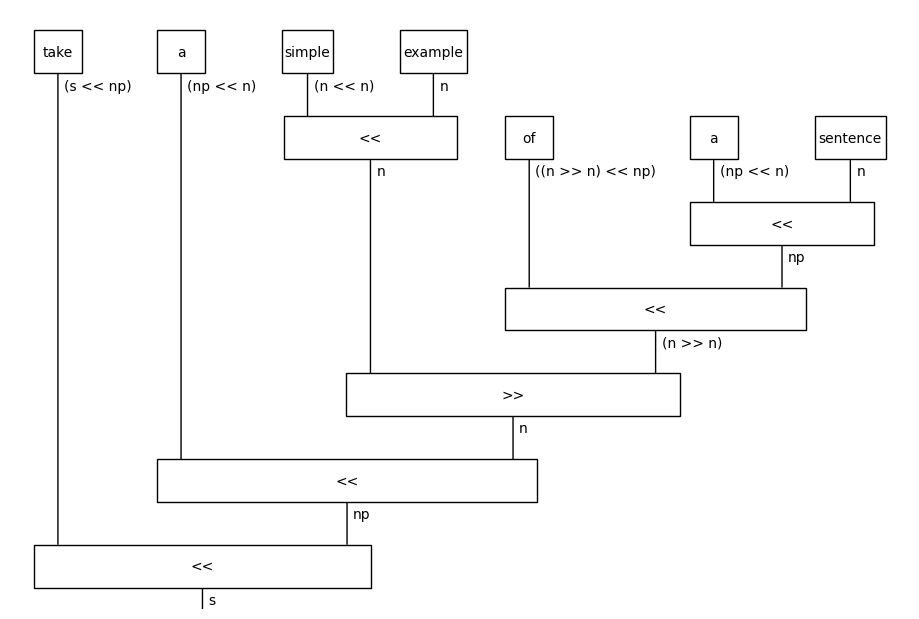

In [2]:
s, np, n = categorial.Ty("s"), categorial.Ty("np"), categorial.Ty("n")

take, a, simple = (s << np)("take"), (np << n)("a"), (n << n)("simple")
example, sentence = n("example"), n("sentence")
of = ((n >> n) << np)("of")

parse = take(a(simple(example)(of(a(sentence)), left=True)))
assert parse.cod == s

parse.eval().foliation().draw(figsize=(9, 6))

## Step 1b: from words to lambda terms

A :class:`Lexicon` is a functor from categorial diagrams to abstract
diagrams: it sends each word to an (almost) linear lambda term. The heads
of the answer are **free variables** named after the words, so the
meaning of the sentence is an almost-linear term whose normal form is the
syntax tree of the answer. We do not normalise it syntactically: the
token machine will compute the normal form by travelling around the
diagram.

In [3]:
N, NP, S = Ty("N"), Ty("NP"), Ty("S")
TAKE, A = Variable("TAKE", NP >> S), Variable("A", N >> NP)
SIMPLE, OF = Variable("SIMPLE", N >> N), Variable("OF", N >> (NP >> N))
EXAMPLE, SENTENCE = Variable("EXAMPLE", N), Variable("SENTENCE", N)

lexicon = Lexicon(
    ob_map={s: S, np: NP, n: N},
    ar_map={
        take: NP(lambda p: TAKE(p)),
        a: N(lambda x: A(x)),
        simple: N(lambda x: SIMPLE(x)),
        of: NP(lambda y: N(lambda x: OF(x)(y))),
        example: EXAMPLE,
        sentence: SENTENCE})

meaning = lexicon(parse)
WORDS = (TAKE, A, SIMPLE, EXAMPLE, OF, SENTENCE)
truth = BohmTree.from_term(meaning, scope=WORDS)
print(meaning)
print("normal form:", truth.to_term(WORDS))

NP(lambda p: TAKE(p))(N(lambda x: A(x))(NP(lambda y: N(lambda x: OF(x)(y)))(N(lambda x: A(x))(SENTENCE))(N(lambda x: SIMPLE(x))(EXAMPLE))))
normal form: TAKE(A(OF(SIMPLE(EXAMPLE))(A(SENTENCE))))


## Step 2: the Zeilberger map and its bubbles

:meth:`TermBase.to_map` encodes the meaning as a combinatorial map: one
`@` node per application, one `λ` node per abstraction, one `δ` node per
copied variable, with the free variables as inputs and the root as
output. We bracket the term tree into bubbles of a maximal size, walking
bottom-up in the same postorder as ``to_map`` creates its boxes: each
subtree keeps an open bracket which closes into a bubble as soon as it
reaches the maximal size, and every `δ` node is a bubble of its own.
The same walk gives a tidy tree layout for the display of step 5.

In [4]:
from discopy.closed import Constant, Application, Abstraction

cmap = meaning.to_map()
print(len(cmap.boxes), "boxes:", " ".join(box.name for box in cmap.boxes))


def bracket(term, cmap, max_size=4):
    """Bracket the term tree into bubbles of at most ``max_size`` boxes."""
    bubbles, counter = [], [0]

    def close(opens):
        if opens:
            bubbles.append(tuple(opens))
        return []


    def go(term):
        if isinstance(term, Constant):
            counter[0] += 1
            return [counter[0] - 1]
        if isinstance(term, Variable):
            return []
        if isinstance(term, Application):
            children = [go(term.func), go(term.args)]
        else:
            children = [go(term.body)]
        opens = sum(children, [])
        if len(opens) + 1 > max_size:
            opens = sum(map(close, children), [])
        counter[0] += 1
        return opens + [counter[0] - 1]

    close(go(term))
    for index, box in enumerate(cmap.boxes):
        if box.name == "δ":
            bubbles.append((index, ))
    bubble_of = {
        box: b for b, bubble in enumerate(bubbles) for box in bubble}
    assert sorted(bubble_of) == list(range(len(cmap.boxes)))
    return bubbles, bubble_of


def layout(term):
    """Tree positions for the boxes of ``term.to_map()``, mirroring the
    postorder of its creation, with one column per variable occurrence
    and the parent-child edges between the boxes of the tree."""
    boxes, leaves, edges, next_leaf = [], [], [], [0]

    def go(term, depth):
        if isinstance(term, (Constant, Variable)):
            x = next_leaf[0]
            next_leaf[0] += 1
            (boxes if isinstance(term, Constant) else leaves).append(
                (term.name, x, depth))
            return x, len(boxes) - 1 if isinstance(term, Constant) else None
        if isinstance(term, Application):
            (x_func, root_func) = go(term.func, depth + 1)
            (x_args, root_args) = go(term.args, depth + 1)
            x, roots = (x_func + x_args) / 2, (root_func, root_args)
        else:
            x, root = go(term.body, depth + 1)
            roots = (root, )
        boxes.append(("@" if isinstance(term, Application) else "λ",
                      x, depth))
        edges.extend((len(boxes) - 1, root)
                     for root in roots if root is not None)
        return x, len(boxes) - 1

    go(term, 0)
    return boxes, leaves, edges


bubbles, bubble_of = bracket(meaning, cmap, max_size=4)
boxes_layout, leaves_layout, tree_edges = layout(meaning)
assert [name for name, _, _ in boxes_layout]\
    == [box.name for box in cmap.boxes if box.name != "δ"]
print("bubbles:", bubbles)

19 boxes: @ λ @ λ @ @ λ λ @ λ @ @ @ λ @ @ @ @ δ
bubbles: [(4, 5, 6, 7), (8, 9, 10), (11,), (12, 13, 14), (0, 1), (2, 3, 15, 16), (17,), (18,)]


## Step 3: the token machine

The rules are the standard ones of the interaction abstract machine, with
the token carrying a pair of stacks: entering an `@` or `λ` box through
an auxiliary port pushes the symbol of that port onto the multiplicative
stack and exits through the principal, entering through the principal
pops the top symbol and exits through the auxiliary it names — an
`@`-pushed symbol popped by a `λ` box is exactly beta reduction. A `δ`
box pushes the occurrence it was entered through onto the exponential
stack and pops it to route the token back to the same occurrence.

The decoder plays the **opponent strategy** at the input ports of the
map, i.e. game semantics made operational: the token starts at the root
with empty stacks and travels down to the head variable of the normal
form; the `@₀` prefix of its stack spells out the number of arguments.
To decode the ``j``-th subtree the opponent replies with
``λ₀ⁱ⁻¹ · λ₁``, diverting the token into the ``j``-th argument on its
way back — one token journey per node of the answer.

In [5]:
ROLES = {"@": (0, (2, 1)), "λ": (1, (0, 2))}
A0, A1, L0, L1 = ("@", 0), ("@", 1), ("λ", 0), ("λ", 1)


def logical_ports(cmap, index):
    """The ports of a box with the codomain in logical order."""
    ports = cmap._box_port_indices[index]
    arity = len(cmap.boxes[index].dom)
    return ports[:arity] + tuple(reversed(ports[arity:]))


def port_table(cmap):
    """Map each port of the map to its box, box name and logical wire."""
    return {port: (index, box.name, wire)
            for index, box in enumerate(cmap.boxes)
            for wire, port in enumerate(logical_ports(cmap, index))}


def spine(mstack):
    """The number of ``@₀`` symbols on top of the stack."""
    arity = 0
    while mstack and mstack[0] == A0:
        arity, mstack = arity + 1, mstack[1:]
    assert not mstack, f"unexpected symbols under the spine: {mstack}"
    return arity


def run(cmap, plan, trace=None, max_steps=100_000):
    """One query: the token starts at the root with empty stacks and the
    decoder plays opponent at the input ports, following ``plan`` (a list
    of child indices) down to the head of the addressed node. Returns the
    input port of the head reached and its number of arguments."""
    root, table = cmap.n_ports - 1, port_table(cmap)
    port, stack, plan = cmap.edges[root], ((), ()), list(plan)
    for _ in range(max_steps):
        if trace is not None:
            trace.append((port, stack))
        mstack, estack = stack
        if port < len(cmap.dom):
            if not plan:
                return port, spine(mstack)
            j = plan.pop(0)
            assert j < spine(mstack), "no such argument"
            port, stack = cmap.edges[port], ((L0, ) * j + (L1, ), estack)
            continue
        assert port != root, "the token exited at the root"
        index, name, wire = table[port]
        if name == "δ":
            if wire == 0:
                out_wire, estack = estack[0], estack[1:]
            else:
                estack, out_wire = (wire, ) + estack, 0
        else:
            principal, auxes = ROLES[name]
            if wire == principal:
                (kind, j), mstack = mstack[0], mstack[1:]
                out_wire = auxes[j]
            else:
                mstack = ((name, auxes.index(wire)), ) + mstack
                out_wire = principal
        stack = mstack, estack
        port = cmap.edges[logical_ports(cmap, index)[out_wire]]
    raise RuntimeError("max steps exceeded")


def decode(cmap, query, max_nodes=100):
    """Incremental readback: one ``query`` per node, breadth first."""
    varname_of = {
        port: getattr(cmap.ports[port].obj.inside[0], "varname", None)
        for port in range(len(cmap.dom))}
    nodes, todo = {}, [()]
    while todo and len(nodes) < max_nodes:
        address = todo.pop(0)
        port, arity = query(address)
        nodes[address] = (varname_of[port], arity)
        todo.extend(address + (j, ) for j in range(arity))
    return nodes


trace = []
nodes = decode(cmap, lambda address: run(cmap, address, trace=trace))
for address, node in sorted(nodes.items()):
    print(f"{str(address):15} -> {node}")
print(len(trace), "steps over", len(nodes), "token journeys")

()              -> ('TAKE', 1)
(0,)            -> ('A', 1)
(0, 0)          -> ('OF', 2)
(0, 0, 0)       -> ('SIMPLE', 1)
(0, 0, 0, 0)    -> ('EXAMPLE', 0)
(0, 0, 1)       -> ('A', 1)
(0, 0, 1, 0)    -> ('SENTENCE', 0)
176 steps over 7 token journeys


In [6]:
def check(nodes, tree, address=()):
    """The decoded nodes match the Böhm tree of the normal form."""
    head, arity = nodes[address]
    assert head == WORDS[tree.head].name and arity == len(tree.args)
    for j, arg in enumerate(tree.args):
        check(nodes, arg, address + (j, ))


check(nodes, truth)

## Step 3b: compile the bubbles to quantum circuits

Between two boundary crossings the token's path through a bubble is
deterministic and reversible, so the visits of a bubble form a partial
injection from entry states to exit states. We record the visits of the
reference run, complete each partial injection to a **permutation
unitary** and compile it to a circuit: the token in-state prepares a
computational basis state with one ``Rx`` rotation per qubit (the
circuit's parameters), the permutation unitary is applied, and the
measurement outcome — sharp, since permutations send basis states to
basis states — is decoded back to the token out-state.

{0: '3 visits on 2 qubits', 1: '2 visits on 1 qubits', 2: '3 visits on 2 qubits', 3: '2 visits on 1 qubits', 4: '2 visits on 1 qubits', 5: '3 visits on 2 qubits', 6: '2 visits on 1 qubits', 7: '4 visits on 2 qubits'}


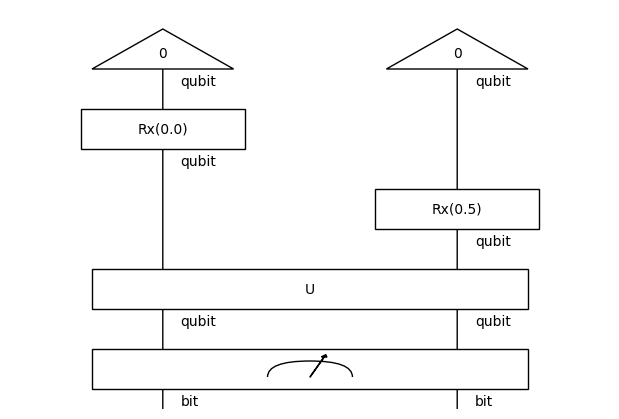

In [7]:
import numpy as np
from discopy.quantum import qubit, Ket, Measure, Rx
from discopy.quantum.gates import QuantumGate


def bubble_visits(cmap, bubble_of, trace):
    """Cut a trace into visits: maximal runs of steps inside one bubble,
    from an entry state ``(port, stacks)`` to the state just after."""
    table = port_table(cmap)
    visits, current, entry = [], None, None
    for port, stack in trace + [(None, None)]:
        bubble = None if port is None or port not in table\
            else bubble_of[table[port][0]]
        if current is not None and bubble != current:
            visits.append((current, entry, (port, stack)))
        if bubble != current:
            entry = (port, stack)
        current = bubble
    return [visit for visit in visits if visit[0] is not None]


def compile_bubble(table):
    """Compile a visit table into a state codebook and a permutation."""
    inputs = sorted(table.keys(), key=repr)
    outputs = sorted(set(table.values()), key=repr)
    n_qubits = max(1, int(np.ceil(np.log2(
        max(len(inputs), len(outputs))))))
    dim = 2 ** n_qubits
    matrix, rows, columns = np.zeros((dim, dim)), set(), set()
    for i, state in enumerate(inputs):
        j = outputs.index(table[state])
        matrix[j, i] = 1
        rows.add(j), columns.add(i)
    free = [j for j in range(dim) if j not in rows]
    for i in range(dim):
        if i not in columns:
            matrix[free.pop(0), i] = 1
    gate = QuantumGate("U", qubit ** n_qubits, qubit ** n_qubits,
                       data=matrix.transpose().flatten())
    return inputs, outputs, n_qubits, gate


def circuit(compiled, i):
    """The circuit called when the token enters a bubble in state ``i``:
    basis state preparation, permutation unitary, measurement."""
    _, _, n_qubits, gate = compiled
    bits = [(i >> k) & 1 for k in reversed(range(n_qubits))]
    prep = Ket(*(0, ) * n_qubits)
    for k, bit in enumerate(bits):
        prep >>= qubit ** k @ Rx(bit / 2) @ qubit ** (n_qubits - k - 1)
    return prep >> gate >> Measure(n_qubits)


def quantum_call(compiled, state):
    """One bubble call, reading the exit state off the measurement."""
    inputs, outputs, n_qubits, _ = compiled
    i = inputs.index(state)
    probs = np.array(circuit(compiled, i).eval().array).real
    outcome = np.unravel_index(np.argmax(probs), probs.shape)
    assert np.isclose(probs[outcome], 1), "the measurement is not sharp"
    j = sum(bit << k for k, bit in enumerate(reversed(outcome)))
    return outputs[j], (i, j)


tables = {}
for bubble, entry, exit in bubble_visits(cmap, bubble_of, trace):
    assert tables.setdefault(bubble, {}).setdefault(entry, exit) == exit
for table in tables.values():
    assert len(set(table.values())) == len(table), "not injective"

compiled = {
    bubble: compile_bubble(table) for bubble, table in tables.items()}
print({bubble: f"{len(table)} visits on {compiled[bubble][2]} qubits"
       for bubble, table in sorted(tables.items())})
circuit(compiled[0], 1).draw(figsize=(6, 4))

## Step 4: the outside as a Python function with disjoint union

The bracketed diagram is one big endo-function on the disjoint union of
the token states over the ports of the map, built as a
:class:`discopy.python.additive.Function` — a token is precisely a value
with a tag saying which wire it sits on. Token passing is the **additive
trace** of this function over the internal ports: what remains is one
environment interaction per call, with the input ports and the root as
boundary. Each internal step is a quantum circuit call, recorded as an
event for the display of step 5.

In [8]:
from discopy.python.additive import Function

d, root = len(cmap.dom), cmap.n_ports - 1
boundary = list(range(d)) + [root]
internal = [p for p in range(cmap.n_ports) if p not in boundary]
comp_of_port = {p: i for i, p in enumerate(boundary + internal)}
port_of_comp = dict(enumerate(boundary + internal))
events = []


def step_inside(stacks, tag=0):
    port = port_of_comp[tag]
    if port in boundary:
        events.append(("env", port, stacks))
        return stacks, comp_of_port[cmap.edges[port]]
    bubble = bubble_of[port_table(cmap)[port][0]]
    (exit_port, new_stacks), (i, j) = quantum_call(
        compiled[bubble], (port, stacks))
    events.append(("circuit", bubble, i, j))
    return new_stacks, comp_of_port[exit_port]


step = Function(step_inside, dom=(object, ) * cmap.n_ports,
                cod=(object, ) * cmap.n_ports)
machine = step.trace(len(internal))


def quantum_query(address):
    """Navigate to the head of the addressed node through the traced
    additive function, each bubble call running a quantum circuit."""
    events.append(("query", tuple(address)))
    stacks, comp = machine(((), ()), comp_of_port[root])
    events.append(("env", port_of_comp[comp], stacks))
    for j in list(address):
        mstack, estack = stacks
        assert j < spine(mstack), "no such argument"
        stacks, comp = machine(((L0, ) * j + (L1, ), estack), comp)
        events.append(("env", port_of_comp[comp], stacks))
    return port_of_comp[comp], spine(stacks[0])


quantum_nodes = decode(cmap, quantum_query)
assert quantum_nodes == nodes
print("the quantum run decodes the same answer in", len(
    [e for e in events if e[0] == "circuit"]), "circuit calls")

the quantum run decodes the same answer in 77 circuit calls


## Step 5: slide through the generation

The whole process in a two-pane interface. On top, the parsed diagram
bracketed into rectangular bubbles: inside each rectangle lives its compiled
quantum circuit, drawn as horizontal qubit lines read left to right —
the token's parameters set the basis state on the left, the permutation
unitary sits in the middle, the measurement on the right. The wires
between the rectangles, the words below and the root above are the
classical outside, and the position of the token is the red dot. At the
bottom, the state of the decoded answer, one subtree at a time. Drag
the slider — or press play — to travel forward in time and watch the
answer converge.

In [9]:
import json
from IPython.display import HTML

COLOURS = ["#8ecae6", "#ffb703", "#90be6d", "#f28482", "#cdb4db",
           "#f9c74f", "#80ced7", "#ffafcc", "#b5e48c", "#e9c46a"]
RECT_W, COL_W, ROW_H, MARGIN = 150, 180, 150, 60

table = port_table(cmap)
varname_of = {
    port: getattr(cmap.ports[port].obj.inside[0], "varname", None)
    for port in range(d)}
delta_bubbles = [b for b, members in enumerate(bubbles)
                 if cmap.boxes[members[0]].name == "δ"]
term_bubbles = [b for b in range(len(bubbles))
                if b not in delta_bubbles]

quotient = {}
for i, j in tree_edges:
    if bubble_of[i] != bubble_of[j]:
        quotient.setdefault(bubble_of[i], []).append(bubble_of[j])
root_bubble = bubble_of[len(boxes_layout) - 1]

rectangle, next_leaf = {}, [0]


def tidy(b, depth):
    """Tidy layout of the quotient tree: the bubbles are its nodes."""
    kids = quotient.get(b, [])
    if not kids:
        x = next_leaf[0]
        next_leaf[0] += 1
    else:
        xs = [tidy(kid, depth + 1) for kid in kids]
        x = sum(xs) / len(xs)
    rectangle[b] = (x, depth)
    return x


tidy(root_bubble, 0)
n_rows = max(depth for _, depth in rectangle.values()) + 1


def height(b):
    return 40 + 18 * compiled[b][2]


def centre(b):
    x, depth = rectangle[b]
    return MARGIN + RECT_W / 2 + x * COL_W, MARGIN + 40 + depth * ROW_H


def anchor(port):
    if port in table:
        return centre(bubble_of[table[port][0]])
    if port < d:
        return word_position[port]
    x, y = centre(root_bubble)
    return x, y - height(root_bubble) / 2 - 45


for b in delta_bubbles:
    xs = [centre(bubble_of[table[cmap.edges[p]][0]])[0]
          for p in logical_ports(cmap, bubbles[b][0])
          if cmap.edges[p] in table]
    rectangle[b] = ((sum(xs) / len(xs) - MARGIN - RECT_W / 2) / COL_W,
                 n_rows - 0.4)

word_position, means = {}, {}
for p in range(d):
    means[p] = centre(bubble_of[table[cmap.edges[p]][0]])[0]
row, gap, x = MARGIN + 100 + n_rows * ROW_H, 92, -float("inf")
for p in sorted(range(d), key=lambda p: means[p]):
    x = max(means[p], x + gap)
    word_position[p] = (x, row)

In [10]:
def circuit_glyph(b):
    """The circuit of a bubble: qubit lines left to right, the token's
    parameters, the permutation unitary and the measurements."""
    n_qubits = compiled[b][2]
    x, y = centre(b)
    w, h = RECT_W, height(b)
    left, right = x - w / 2, x + w / 2
    parts = []
    for k in range(n_qubits):
        line = y - 9 * (n_qubits - 1) + 18 * k
        parts.append(
            f'<line x1="{left + 14:.0f}" y1="{line:.0f}"'
            f' x2="{right - 14:.0f}" y2="{line:.0f}"'
            ' stroke="#333" stroke-width="1.2"/>'
            f'<rect x="{left + 20:.0f}" y="{line - 6:.0f}" width="12"'
            ' height="12" fill="white" stroke="#333"/>'
            f'<text x="{left + 26:.0f}" y="{line + 3:.0f}"'
            ' text-anchor="middle" font-size="8">Rx</text>'
            f'<rect x="{right - 34:.0f}" y="{line - 6:.0f}" width="14"'
            ' height="12" fill="white" stroke="#333"/>'
            f'<path d="M {right - 31:.0f} {line + 3:.0f}'
            f' a 4 4 0 0 1 8 0" fill="none" stroke="#333"/>'
            f'<line x1="{right - 27:.0f}" y1="{line + 3:.0f}"'
            f' x2="{right - 23:.0f}" y2="{line - 4:.0f}"'
            ' stroke="#333"/>')
    top = y - 9 * (n_qubits - 1) - 8
    parts.append(
        f'<rect x="{x - 13:.0f}" y="{top:.0f}" width="26"'
        f' height="{18 * (n_qubits - 1) + 16:.0f}" fill="white"'
        ' stroke="#333" stroke-width="1.2"/>'
        f'<text x="{x:.0f}" y="{y + 4:.0f}" text-anchor="middle"'
        ' font-size="12">U</text>')
    return "".join(parts)


def build_svg():
    width = 2 * MARGIN + RECT_W + COL_W * max(
        x for x, _ in rectangle.values())
    heights = max(y for _, y in word_position.values()) + MARGIN
    parts = [f'<svg id="map" viewBox="0 0 {width:.0f} {heights:.0f}"'
             ' xmlns="http://www.w3.org/2000/svg">']
    seen = {}
    for p in range(cmap.n_ports):
        q = cmap.edges[p]
        if p > q or (p in table and q in table
                     and bubble_of[table[p][0]] == bubble_of[table[q][0]]):
            continue
        (x1, y1), (x2, y2) = anchor(p), anchor(q)
        pair = (round(x1 + x2), round(y1 + y2))
        shift = 8 * seen.get(pair, 0)
        seen[pair] = seen.get(pair, 0) + 1
        parts.append(
            f'<line x1="{x1 + shift:.0f}" y1="{y1:.0f}"'
            f' x2="{x2 + shift:.0f}" y2="{y2:.0f}" stroke="#888"'
            ' stroke-width="1.3"/>')
    for b in range(len(bubbles)):
        x, y = centre(b)
        w, h = RECT_W, height(b)
        colour = COLOURS[b % len(COLOURS)]
        parts.append(
            f'<g class="bubble">'
            f'<rect x="{x - w / 2:.0f}" y="{y - h / 2:.0f}"'
            f' width="{w}" height="{h:.0f}" fill="white"/>'
            f'<rect x="{x - w / 2:.0f}" y="{y - h / 2:.0f}"'
            f' width="{w}" height="{h:.0f}" fill="{colour}"'
            ' fill-opacity="0.3" stroke="#333" stroke-width="1.5"'
            ' class="rectangle"/>'
            f'<text x="{x - w / 2 + 6:.0f}" y="{y - h / 2 + 13:.0f}"'
            f' font-size="10" fill="#555">{b}</text>'
            + circuit_glyph(b) + '</g>')
    for p in range(d):
        x, y = word_position[p]
        parts.append(
            f'<rect x="{x - 40:.0f}" y="{y - 15:.0f}" width="80"'
            ' height="30" rx="6" fill="#eee" stroke="#333"/>'
            f'<text x="{x:.0f}" y="{y + 5:.0f}" text-anchor="middle"'
            f' font-size="12">{varname_of[p]}</text>')
    x, y = anchor(root)
    parts.append(f'<text x="{x:.0f}" y="{y - 6:.0f}"'
                 ' text-anchor="middle" font-size="12" fill="#666">'
                 'root</text>')
    parts.append('<circle id="token" r="8" fill="crimson"'
                 ' stroke="white" stroke-width="2"/></svg>')
    return "".join(parts)


def build_frames():
    """One frame per event of the quantum run."""
    frames, partials = [], ["?"]
    order, query = list(quantum_nodes.items()), -1
    for event in events:
        if event[0] == "query":
            if frames:
                frames[-1]["k"] += 1
            query += 1
            continue
        if event[0] == "circuit":
            _, b, i, j = event
            x, y = centre(b)
            frame = {"bubble": b, "label": f"U|{i}⟩ = |{j}⟩"}
        else:
            _, port, (mstack, estack) = event
            x, y = anchor(port)
            name = "root" if port == root else varname_of[port]
            stacks = "·".join(map(SYMBOL.get, mstack)) or "ε"
            frame = {"bubble": None,
                     "label": f"{name}   m = {stacks}"}
        address = order[query][0] if 0 <= query < len(order) else ()
        frames.append(frame | {
            "x": round(x, 1), "y": round(y, 1), "q": query + 1,
            "address": list(address), "k": query})
    frames[-1]["k"] += 1
    known = {}
    for address, node in order:
        known[address] = node
        current = dict(known)

        def render(address):
            if address not in current:
                return "?"
            head, arity = current[address]
            return head + "".join(
                "(" + render(address + (j, )) + ")" for j in range(arity))
        partials.append(render(()))
    return frames, partials


SYMBOL = {A0: "@₀", A1: "@₁", L0: "λ₀", L1: "λ₁"}
frames, partials = build_frames()
print(len(frames), "frames;", "final answer:", partials[-1])

125 frames; final answer: TAKE(A(OF(SIMPLE(EXAMPLE))(A(SENTENCE))))


In [11]:
TEMPLATE = """
<div id="goi-demo">
<style>
#goi-demo svg { display: block; margin: auto; max-width: 100%;
                max-height: 60vh; }
#goi-demo .controls { display: flex; gap: 12px; align-items: center;
                      padding: 8px 0; }
#goi-demo .controls input { flex: 1; }
#goi-demo .status { font-family: monospace; font-size: 13px; }
#goi-demo .answer { font-family: monospace; font-size: 20px;
                    padding: 6px 0; border-top: 2px solid #ccc; }
#goi-demo .answer .hole { color: #bbb; }
#goi-demo .bubble.active .rectangle { fill-opacity: 0.65; }
</style>
__SVG__
<div class="controls">
  <button id="goi-play">▶</button>
  <input type="range" id="goi-slider" min="0" value="0"/>
  <span id="goi-counter"></span>
</div>
<div class="status" id="goi-status"></div>
<div class="answer" id="goi-answer"></div>
<script>
(function () {
  const DATA = __DATA__;
  const frames = DATA.frames, partials = DATA.partials;
  const slider = document.getElementById("goi-slider");
  const token = document.getElementById("token");
  slider.max = frames.length - 1;
  let playing = null;
  function show(i) {
    const f = frames[i];
    token.setAttribute("cx", f.x);
    token.setAttribute("cy", f.y);
    document.querySelectorAll("#goi-demo .bubble").forEach(
      (el, b) => el.classList.toggle("active", b === f.bubble));
    document.getElementById("goi-counter").textContent =
      (i + 1) + " / " + frames.length;
    document.getElementById("goi-status").textContent =
      "journey " + f.q + " to node [" + f.address + "]   " + f.label +
      (f.bubble === null ? "" : "   (bubble " + f.bubble + ")");
    document.getElementById("goi-answer").innerHTML =
      partials[f.k].replaceAll("?", '<span class="hole">?</span>');
  }
  slider.addEventListener("input", () => show(+slider.value));
  document.getElementById("goi-play").addEventListener("click", () => {
    if (playing) { clearInterval(playing); playing = null; return; }
    playing = setInterval(() => {
      if (+slider.value >= frames.length - 1) {
        clearInterval(playing); playing = null; return; }
      slider.value = +slider.value + 1;
      show(+slider.value);
    }, 250);
  });
  show(0);
})();
</script></div>
"""

html = TEMPLATE.replace("__SVG__", build_svg()).replace(
    "__DATA__", json.dumps({"frames": frames, "partials": partials}))
HTML(html)

## What this shows, and what comes next

The answer of the sentence converges to
``TAKE(A(OF(SIMPLE(EXAMPLE))(A(SENTENCE))))`` without the meaning ever
being beta-reduced: the redexes introduced by the lexicon are traversed
dynamically by the token, and each traversal runs through quantum
circuits whose parameters are set — and whose measurements are read —
by a classical token, the outside being nothing but a traced Python
function with disjoint union as tensor.

Some honest limitations, each a pointer for a next iteration:

* the bubble circuits are compiled from the visits of a classical
  reference run, i.e. they are reversible lookups; the next step is to
  compile the `@`/`λ`/`δ` rules symbolically on a bounded stack encoding,
  so the circuits are built before any token flies;
* the lexicon stays in the almost-linear fragment with variable heads,
  which keeps token passing exact; constants-as-oracles (as in the
  `neural-boolean` notebook) would let words act as learned or quantum
  strategies rather than free variables;
* the parse is written by hand — plugging bobcat or spindle in front is
  only a matter of translating their derivations to
  :mod:`discopy.grammar.categorial`, which is what
  :class:`discopy.grammar.abstract.Lexicon` consumes.